In [1]:
from pathlib import Path
import json
import sys

src_path = Path('../src').resolve()
sys.path.insert(0, str(src_path))
from pr_formatter import PRFormatter

formatter = PRFormatter()

## General Analysis - Gemini Flash Lite

In [2]:
def contar_arquivos(caminho):
    return sum(1 for item in Path(caminho).iterdir() if item.is_file())

pasta = Path('../django/prs')
print(f"{contar_arquivos(pasta)} arquivos encontrados.")

18524 arquivos encontrados.


In [3]:
def general_stats(data):
    print(f"{len(data)} arquivos totais processados.")
    count_empty_responses = sum(1 for item in data if item.get('owasp_category') == "NONE")  
    count_issues_responses = len(data) - count_empty_responses
    print(f"{count_empty_responses} arquivos com resposta vazia.")
    print(f"{count_issues_responses} arquivos com issues identificadas.")

In [4]:
with open("../data/django_gemini_3.1-flash-lite_0.json", "r", encoding="utf-8") as f:
    data = json.load(f)
 
general_stats(data)

18544 arquivos totais processados.
16626 arquivos com resposta vazia.
1918 arquivos com issues identificadas.


In [5]:
def analyze_pr_ids(data):
    prs_ids = [item['pr_id'] for item in data]
    prs_ids_pasta = [item.name.replace(".json", "") for item in pasta.iterdir()]

    count_prs_ids_pasta = 0
    not_processed_prs = []
    for id in prs_ids_pasta:
        if id not in prs_ids:
            count_prs_ids_pasta += 1
            not_processed_prs.append(id)
    print(f"{count_prs_ids_pasta} PRs IDs no Django mas não processados.")

    count_invented_prs = 0
    invented_prs = []
    for id in prs_ids:
        if id not in prs_ids_pasta:
            count_invented_prs += 1
            invented_prs.append(id)
    print(f"{count_invented_prs} PRs IDs inventados.")

    count_duplicates = 0
    duplicates = [item for item in prs_ids if prs_ids.count(item) > 1]
    for item in duplicates:
        count_duplicates += 1
    print(f"{count_duplicates} PRs IDs duplicados.")

    return not_processed_prs, invented_prs, duplicates


not_processed_prs, invented_prs, duplicates = analyze_pr_ids(data)

0 PRs IDs no Django mas não processados.
10 PRs IDs inventados.
20 PRs IDs duplicados.


In [7]:
def remove_invented_prs(data, invented_prs):
    invented_ids = set(invented_prs)
    return [item for item in data if item['pr_id'] not in invented_ids]


def resolve_duplicates(data):
    grouped_by_pr_id = {}
    for item in data:
        grouped_by_pr_id.setdefault(item['pr_id'], []).append(item)

    cleaned_data = []
    removed_equal_duplicates = 0
    conflicting_duplicates = {}

    for pr_id, versions in grouped_by_pr_id.items():
        if len(versions) == 1:
            cleaned_data.append(versions[0])
            continue

        first_version = versions[0]
        all_versions_equal = all(version == first_version for version in versions[1:])

        if all_versions_equal:
            cleaned_data.append(first_version)
            removed_equal_duplicates += len(versions) - 1
        else:
            conflicting_duplicates[pr_id] = versions
            cleaned_data.extend(versions)

    print(f"{removed_equal_duplicates} duplicatas idênticas removidas.")

    if conflicting_duplicates:
        print("\nDuplicatas com conteúdo diferente encontradas (revisão manual):")
        for pr_id, versions in conflicting_duplicates.items():
            print(f"\nPR ID: {pr_id} | versões encontradas: {len(versions)}")
            for idx, version in enumerate(versions, start=1):
                print(f"--- Versão {idx} ---")
                print(json.dumps(version, indent=2, ensure_ascii=False))
    else:
        print("Nenhuma duplicata com conteúdo diferente encontrada.")

    return cleaned_data, conflicting_duplicates


data = remove_invented_prs(data, invented_prs)
print(f"{len(invented_prs)} PRs IDs inventados removidos.")

data, conflicting_duplicates = resolve_duplicates(data)

general_stats(data)
not_processed_prs, invented_prs, duplicates = analyze_pr_ids(data)

10 PRs IDs inventados removidos.
10 duplicatas idênticas removidas.
Nenhuma duplicata com conteúdo diferente encontrada.
18524 arquivos totais processados.
16607 arquivos com resposta vazia.
1917 arquivos com issues identificadas.
0 PRs IDs no Django mas não processados.
0 PRs IDs inventados.
0 PRs IDs duplicados.


In [9]:
output_clean_file = '../data/django_gemini_3.1-flash-lite_0_clean.json'
with open(output_clean_file, 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)
print(f"Arquivo limpo salvo em: {output_clean_file}")

Arquivo limpo salvo em: ../data/django_gemini_3.1-flash-lite_0_clean.json


In [7]:
with open("../data/django_gemini_3.1-flash-lite_0_clean.json", "r", encoding="utf-8") as f:
    data = json.load(f)
 
general_stats(data)

18524 arquivos totais processados.
16607 arquivos com resposta vazia.
1917 arquivos com issues identificadas.


In [6]:
new_data = json.load(open('../data/django_gemini_3.1-flash-lite_0_clean.json', 'r', encoding='utf-8'))

categorias_count = {
    "A01: Broken Access Control": 0,
    "A02: Security Misconfiguration": 0,
    "A03: Software Supply Chain Failures": 0,
    "A04: Cryptographic Failures": 0,
    "A05: Injection": 0,
    "A06: Insecure Design": 0,
    "A07: Authentication Failures": 0,
    "A08: Software or Data Integrity Failures": 0,
    "A09: Security Logging and Alerting Failures": 0,
    "A10: Mishandling of Exceptional Conditions": 0
}

other_categories = {}

for item in new_data:
    if item["owasp_category"] != "NONE":
        if item["owasp_category"] in categorias_count:
            categorias_count[item["owasp_category"]] += 1
        else:
            other_categories[item["owasp_category"]] = other_categories.get(item["owasp_category"], 0) + 1
    else:
        pass

total_categorias = sum(categorias_count.values())

print("Contagem por categoria:")
for categoria, count in categorias_count.items():
    percentual = (count / total_categorias * 100) if total_categorias else 0
    print(f"{categoria}: {count} ({percentual:.2f}%)")

Contagem por categoria:
A01: Broken Access Control: 267 (13.93%)
A02: Security Misconfiguration: 327 (17.06%)
A03: Software Supply Chain Failures: 86 (4.49%)
A04: Cryptographic Failures: 112 (5.84%)
A05: Injection: 229 (11.95%)
A06: Insecure Design: 167 (8.71%)
A07: Authentication Failures: 50 (2.61%)
A08: Software or Data Integrity Failures: 178 (9.29%)
A09: Security Logging and Alerting Failures: 103 (5.37%)
A10: Mishandling of Exceptional Conditions: 398 (20.76%)


In [8]:
# Category names that were not in the predefined list
if other_categories:
    print("\nCategorias adicionais encontradas:")
    for categoria, count in other_categories.items():
        print(f"{categoria}: {count}")

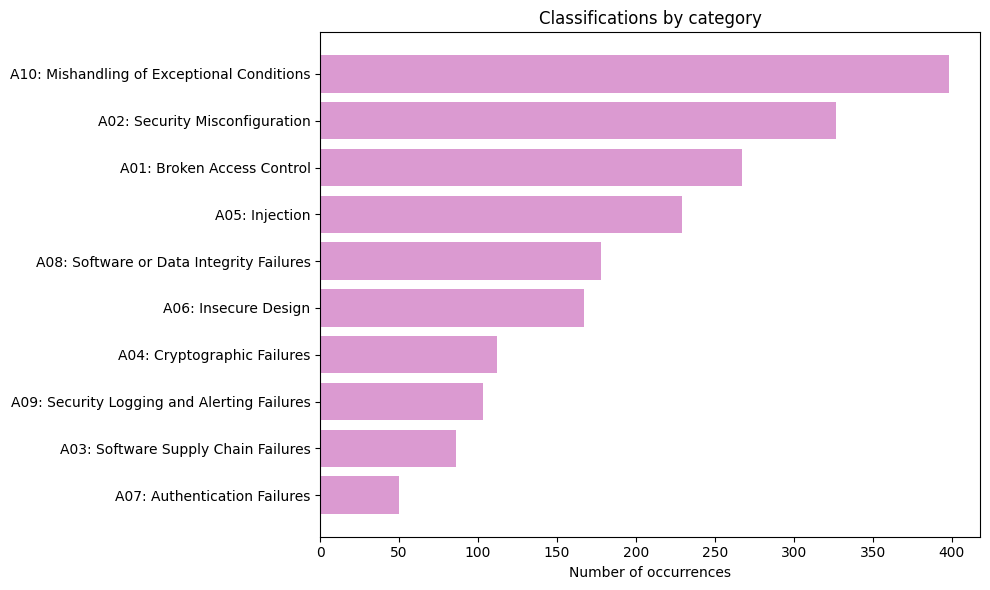

In [10]:
# Ordenar gráfico de barras

import matplotlib.pyplot as plt

categorias_ordenadas = sorted(categorias_count.items(), key=lambda item: item[1], reverse=True)
labels = [categoria for categoria, _ in categorias_ordenadas]
values = [count for _, count in categorias_ordenadas]

plt.figure(figsize=(10,6))
plt.barh(labels, values, color='#db9ad1')
plt.gca().invert_yaxis()
plt.xlabel('Number of occurrences')
plt.title('Classifications by category')
plt.tight_layout()
plt.show()

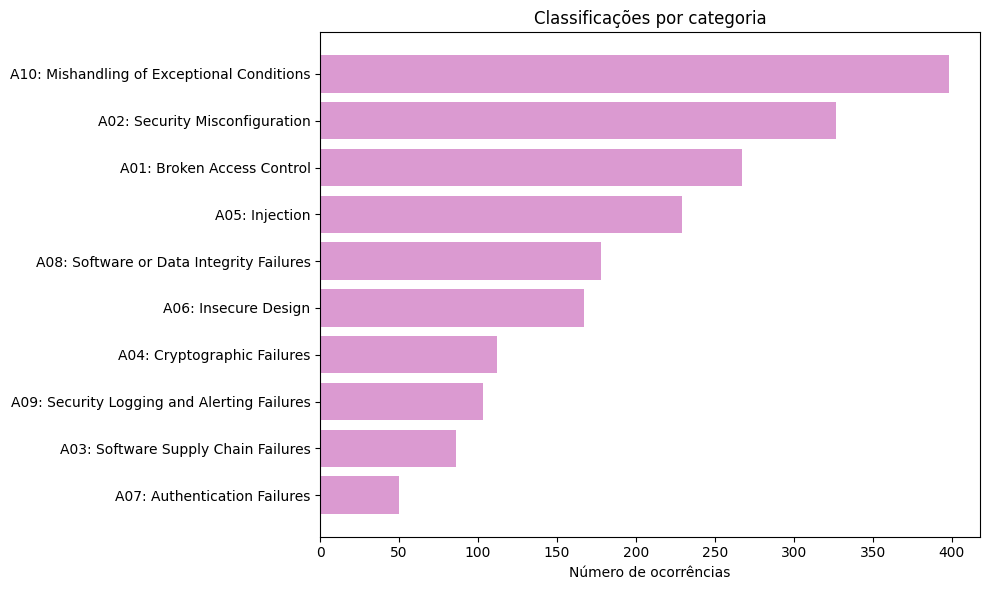

In [11]:
import matplotlib.pyplot as plt

categorias_ordenadas = sorted(categorias_count.items(), key=lambda item: item[1], reverse=True)
labels = [categoria for categoria, _ in categorias_ordenadas]
values = [count for _, count in categorias_ordenadas]

plt.figure(figsize=(10,6))
plt.barh(labels, values, color='#db9ad1')
plt.gca().invert_yaxis()
plt.xlabel('Número de ocorrências')
plt.title('Classificações por categoria')
plt.tight_layout()
plt.show()

## Geração de Planilha Excel para Avaliação

Vamos criar uma planilha Excel com 5% dos PRs de cada categoria para avaliação manual.

In [ ]:
import pandas as pd
import random
import math
from datetime import datetime

# Definir seed para reprodutibilidade
random.seed(42)

In [ ]:
def get_prs_by_category(category_name):
    """Retorna lista de IDs de PRs para uma categoria específica"""
    prs = []
    for item in data:
        if item["owasp_category"] == category_name:
            prs.append({
                'id': item['pr_id'],
                'issue_data': item
            })
    return prs

In [ ]:
def get_pr_formatted_data(pr_id):
    """Retorna dados formatados do PR e saída da LLM"""
    try:
        # Obter dados formatados
        file_path = Path('../django/prs') / f"{pr_id}.json"
        if file_path.exists():
            formatted_pr = formatter.format_pr_discussions(file_path)
        else:
            formatted_pr = f"Arquivo não encontrado: {file_path}"
        
        # Obter saída da LLM
        llm_output = None
        for item in data:
            if item.get('pr_id') == pr_id:
                llm_output = item
                break
        
        return formatted_pr, llm_output
    except Exception as e:
        return f"Erro ao processar {pr_id}: {str(e)}", None

In [54]:
# Coletar dados para Excel
excel_data = []

print("Coletando amostras por categoria:")
print("=" * 50)

for categoria in categorias_count.keys():
    count = categorias_count[categoria]
    if count > 0:
        # Obter todos os PRs da categoria
        prs_categoria = get_prs_by_category(categoria)
        
        # Calcular 5% (mínimo 1, máximo disponível)
        sample_size = max(1, math.ceil(count * 0.05))
        sample_size = min(sample_size, len(prs_categoria))
        
        # Selecionar amostra aleatória
        sample_prs = random.sample(prs_categoria, sample_size)
        
        print(f"{categoria}: {count} total → {sample_size} selecionados")
        
        # Processar cada PR da amostra
        for pr_data in sample_prs:
            pr_id = pr_data['id']
            issue_data = pr_data['issue_data']
            
            # Obter dados formatados
            formatted_pr, llm_output = get_pr_formatted_data(pr_id)
            
            # Adicionar à lista para Excel
            excel_data.append({
                'PR_ID': pr_id,
                'PR_Formatted': str(formatted_pr)[:2000] + '...' if len(str(formatted_pr)) > 2000 else str(formatted_pr),
                'LLM_Output': str(llm_output)[:1000] + '...' if len(str(llm_output)) > 1000 else str(llm_output),
                'Category': categoria,
                'Issue_Description': issue_data.get('summary', None),
                'Evaluation': '',  # Vazio para preenchimento manual
                'Justify': ''      # Vazio para preenchimento manual
            })

print(f"\nTotal de registros coletados: {len(excel_data)}")

Coletando amostras por categoria:
A01: Broken Access Control: 267 total → 14 selecionados
A02: Security Misconfiguration: 327 total → 17 selecionados
A03: Software Supply Chain Failures: 86 total → 5 selecionados
A04: Cryptographic Failures: 112 total → 6 selecionados
A05: Injection: 229 total → 12 selecionados
A06: Insecure Design: 167 total → 9 selecionados
A07: Authentication Failures: 50 total → 3 selecionados
A08: Software or Data Integrity Failures: 178 total → 9 selecionados
A09: Security Logging and Alerting Failures: 103 total → 6 selecionados
A10: Mishandling of Exceptional Conditions: 398 total → 20 selecionados

Total de registros coletados: 101


In [55]:
# Criar DataFrame
df = pd.DataFrame(excel_data)

# Reordenar colunas
column_order = ['PR_ID', 'Category', 'Issue_Description', 'PR_Formatted', 'LLL_Output', 'Evaluation', 'Justify']
df = df[['PR_ID', 'Category', 'Issue_Description', 'PR_Formatted', 'LLM_Output', 'Evaluation', 'Justify']]

# Salvar Excel
output_file = '../evaluation_sample.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='PR_Evaluation', index=False)
    
    # Ajustar largura das colunas
    worksheet = writer.sheets['PR_Evaluation']
    
    # Definir larguras das colunas
    column_widths = {
        'A': 30,  # PR_ID
        'B': 25,  # Category 
        'C': 40,  # Issue_Description
        'D': 80,  # PR_Formatted
        'E': 60,  # LLM_Output
        'F': 15,  # Evaluation
        'G': 40   # Justify
    }
    
    for col, width in column_widths.items():
        worksheet.column_dimensions[col].width = width
        
    # Configurar quebra de texto
    from openpyxl.styles import Alignment
    
    for row in worksheet.iter_rows(min_row=2):  # Pular cabeçalho
        for cell in row:
            if cell.column_letter in ['C', 'D', 'E', 'G']:  # Colunas com texto longo
                cell.alignment = Alignment(wrap_text=True, vertical='top')

print(f"Planilha Excel criada: {output_file}")
print(f"Total de registros: {len(df)}")
print("\nDistribuição por categoria:")
print(df['Category'].value_counts().sort_index())

Planilha Excel criada: ../evaluation_sample.xlsx
Total de registros: 101

Distribuição por categoria:
Category
A01: Broken Access Control                     14
A02: Security Misconfiguration                 17
A03: Software Supply Chain Failures             5
A04: Cryptographic Failures                     6
A05: Injection                                 12
A06: Insecure Design                            9
A07: Authentication Failures                    3
A08: Software or Data Integrity Failures        9
A09: Security Logging and Alerting Failures     6
A10: Mishandling of Exceptional Conditions     20
Name: count, dtype: int64


In [56]:
# Mostrar primeiras linhas como preview
print("Preview dos dados coletados:")
print("=" * 80)

for i, row in df.head(3).iterrows():
    print(f"\n{i+1}. PR: {row['PR_ID']}")
    print(f"   Categoria: {row['Category']}")
    print(f"   Issue: {row['Issue_Description'][:100]}...")
    print(f"   PR Formatado: {str(row['PR_Formatted'])[:150]}...")
    print(f"   LLM Output: {str(row['LLM_Output'])[:100]}...")
    print("-" * 80)

Preview dos dados coletados:

1. PR: PR_kwDOAD-Lgs5XP4iv
   Categoria: A01: Broken Access Control
   Issue: The PR addresses an authorization issue where links were displayed to users who lacked the appropria...
   PR Formatado: {'context': {'repository': 'django/django', 'pr_id': 'PR_kwDOAD-Lgs5XP4iv', 'title': 'Fixes [#25656] Stop displaying links in recent changes when user...
   LLM Output: {'pr_id': 'PR_kwDOAD-Lgs5XP4iv', 'owasp_category': 'A01: Broken Access Control', 'nature': 'FIX/PREV...
--------------------------------------------------------------------------------

2. PR: MDExOlB1bGxSZXF1ZXN0NTk2MzczMzMy
   Categoria: A01: Broken Access Control
   Issue: The PR addresses a security issue where invalid Referer headers could cause CSRF validation failures...
   PR Formatado: {'context': {'repository': 'django/django', 'pr_id': 'MDExOlB1bGxSZXF1ZXN0NTk2MzczMzMy', 'title': 'Fixed #32571 -- Made CsrfViewMiddleware handle inva...
   LLM Output: {'pr_id': 'MDExOlB1bGxSZXF1ZXN0NTk2

## Outras análises

In [ ]:
# Criar saída sem os dicts onde owasp_category é NONE
data_sem_none = [item for item in data if item.get('owasp_category') != "NONE"]

# Salvar saída sem os dicts onde owasp_category é NONE
output_file_sem_none = '../data/django_gemini_3.1-flash-lite_0_clean_only_classified.json'
with open(output_file_sem_none, 'w', encoding='utf-8') as f:
    json.dump(data_sem_none, f, indent=4, ensure_ascii=False)